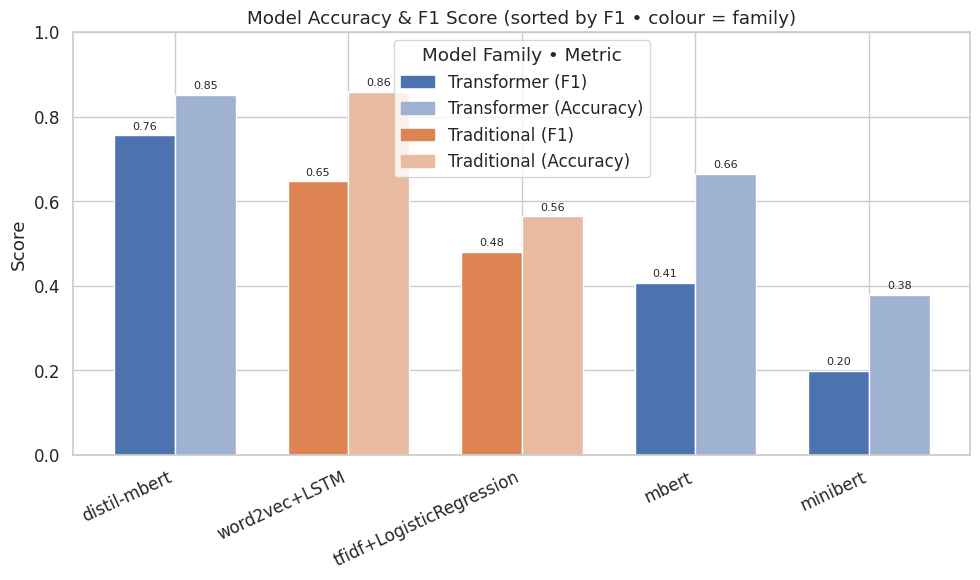

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# --------------------------------------------------------
# Data
# --------------------------------------------------------
models     = ['word2vec+LSTM', 'distil-mbert', 'tfidf+LogisticRegression', 'minibert', 'mbert']
accuracy   = [0.859, 0.8507, 0.5641, 0.3774, 0.6642]
f1_scores  = [0.6464, 0.7554, 0.4792, 0.1993, 0.4068]

family_map = {
    'mbert':              'Transformer',
    'distil-mbert':               'Transformer',
    'minibert':           'Transformer',
    'word2vec+LSTM':            'Traditional',
    'tfidf+LogisticRegression': 'Traditional',
}

df = pd.DataFrame({
    'model':    models,
    'Accuracy': accuracy,
    'F1 Score': f1_scores,
})
df['family'] = df['model'].map(family_map)

# Sort by F1 Score (best → worst)
df = df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

# --------------------------------------------------------
# Plot
# --------------------------------------------------------
sns.set(style='whitegrid', font_scale=1.1)
palette = {'Transformer': '#4c72b0', 'Traditional': '#dd8452'}

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(df))

for i, row in df.iterrows():
    base_color = palette[row['family']]
    lighter    = sns.light_palette(base_color, n_colors=3)[1]

    # F1 Score bar (left)
    ax.bar(x[i] - bar_width/2, row['F1 Score'],
           bar_width, color=base_color)
    # Accuracy bar (right)
    ax.bar(x[i] + bar_width/2, row['Accuracy'],
           bar_width, color=lighter)

# -------  Add value labels on *all* bars  -------
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)

# Axes & title
ax.set_xticks(x)
ax.set_xticklabels(df['model'], rotation=25, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Model Accuracy & F1 Score (sorted by F1 • colour = family)')

# Legend
handles = [
    Patch(color=palette['Transformer'], label='Transformer (F1)'),
    Patch(color=sns.light_palette(palette['Transformer'], n_colors=3)[1],
          label='Transformer (Accuracy)'),
    Patch(color=palette['Traditional'], label='Traditional (F1)'),
    Patch(color=sns.light_palette(palette['Traditional'], n_colors=3)[1],
          label='Traditional (Accuracy)'),
]
ax.legend(handles=handles, title='Model Family • Metric')

plt.tight_layout()
plt.show()